In [1]:
import numpy as np
import pandas as pd
from scipy.stats import gamma
import matplotlib.pyplot as plt

class DengueRtEstimator:
    def __init__(self, population_size=2e8):
        self.population_size = population_size
        # Parameters for serial interval
        self.human_incubation = (4, 7)  # min, max days
        self.infectious_period = 4
        self.mosquito_development = 10
        
    def generate_serial_interval(self, n_days=30):
        """Generate serial interval distribution"""
        # Combine human-mosquito-human cycle
        total_delay = np.random.uniform(
            low=self.human_incubation[0] + self.mosquito_development,
            high=self.human_incubation[1] + self.mosquito_development + self.infectious_period,
            size=1000
        )
        # Fit gamma distribution
        shape, loc, scale = gamma.fit(total_delay)
        x = np.arange(n_days)
        si = gamma.pdf(x, shape, loc, scale)
        return si / si.sum()
    
    def estimate_rt(self, cases, window_size=7):
        """Estimate Rt using sliding window"""
        si = self.generate_serial_interval()
        rt_estimates = []
        
        for t in range(window_size, len(cases)):
            # Get window of cases
            window = cases[t-window_size:t]
            # Calculate Rt using maximum likelihood
            numerator = window[-1]
            denominator = np.sum(window[:-1] * si[:window_size][::-1])
            rt = numerator / denominator if denominator > 0 else np.nan
            rt_estimates.append(rt)
            
        return rt_estimates

    def calculate_confidence_intervals(self, rt_estimates, cases, window_size=7):
        """Calculate 95% CI using parametric bootstrap"""
        si = self.generate_serial_interval()
        ci_lower, ci_upper = [], []
        
        for t in range(len(rt_estimates)):
            # Generate bootstrap samples
            samples = np.random.poisson(
                rt_estimates[t] * np.sum(cases[t:t+window_size] * si[:window_size]),
                size=1000
            )
            # Calculate quantiles
            ci_lower.append(np.quantile(samples, 0.025))
            ci_upper.append(np.quantile(samples, 0.975))
            
        return np.array(ci_lower), np.array(ci_upper)

In [2]:
%reload_ext autoreload
%autoreload 3
import os
from pathlib import Path
import sys
sys.path.append(str(Path(os.getcwd()).parent / 'src'))
from forecastpnn.utils.data_functions import get_dataset
import torch
torch.use_deterministic_algorithms(True) # reproducibility
import pandas as pd

from forecastpnn.utils.train_utils import SubsetSampler as SS
from forecastpnn.utils.constants import RANDOM_SEED

data = pd.read_csv('../data/derived/DENGSP.csv')
dl = get_dataset(data, 'DT_SIN_PRI', weeks_in=False, weeks_out=False, past_units=30, return_df=True, filter_year_min=2013, filter_year_max=2020, dow=False)

/var/folders/xr/mqd4g8995xqfhcvcyvr2smdc0000gn/T/ipykernel_3493/2340205705.py:15: DtypeWarning: Columns (7,11,23,45,46,47,55,65,69,75,86,102) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('../data/derived/DENGSP.csv')


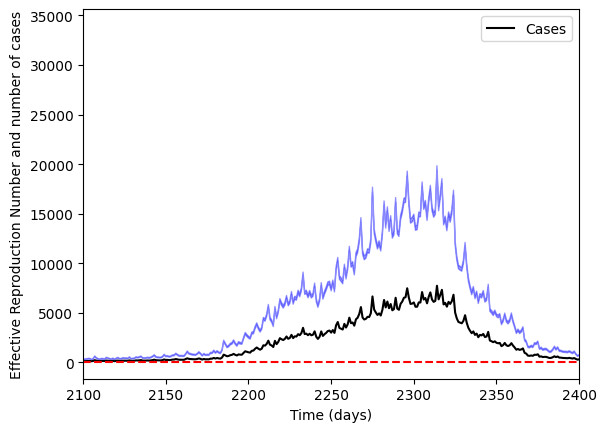

In [18]:
cases = dl.values

# Initialize estimator
estimator = DengueRtEstimator()

# Calculate Rt
rt = estimator.estimate_rt(cases)
ci_lower, ci_upper = estimator.calculate_confidence_intervals(rt, cases)

# Plot results
plt.plot(cases[6:], 'k-', label='Cases')
#plt.plot(rt, 'b-', label='Rt')
plt.fill_between(range(len(rt)), ci_lower, ci_upper, color='b', alpha=0.4)
plt.axhline(y=1, color='r', linestyle='--')
plt.xlabel('Time (days)')
plt.ylabel('Effective Reproduction Number and number of cases')
plt.xlim(2100, 2400)
plt.legend()
plt.show()